# TP1 Transfert de chaleur en milieu poreux

__4 séances__

L'objectif est de développer un module python qui résout le transfert de chaleur en milieu poreux en régime transitoire thermique.


## 1. L'interface nappe-rivière en régime permanent

L'interface nappe-rivière est ici représentée par une portion de zone hyporhéique mono-dimensionnelle de hauteur h.

Le couple d'équations régissant le transfert de chaleur correspond d'une part à la résolution du régime permanent hydraulique (loi de Darcy):

$ \boldsymbol{q} = -K \boldsymbol{\nabla} H $

couplée à l'équation de transfert de chaleur

$ \rho_w c_w \boldsymbol{q} \cdot \boldsymbol{\nabla} \theta - \lambda_m \Delta \theta = 0 $


avec $\boldsymbol{q}$, le débit spécifique [$m.s^{-1}$],  
$H$, la charge [$m$]  
$K$, la perméabilité [$m.s^{-1}$],  
$\theta$, la température [$K$],  
$\rho_w$, la densité de l'eau [$kg.m^{-3}$],  
$c_w$ la capacité calorifique spécifique de l'eau [$J.kg^{-1}.K^{-1}$],  
$\lambda_m$ [$W.m^{-1}.K^{-1}$] la conductivité thermique du milieu poreux équivalent, avec $\lambda_m = \left( n \sqrt{\lambda_w} + (1-n) \sqrt{\lambda_s} \right)^2$ où $n$ est la porosité du milieu, et les indices $w$ et $s$ dénotent respectivement l'eau et le solide pur.

$\boldsymbol{\nabla}$ est un opérateur différenciel et $\Delta$ le Laplacien. 
Les symboles en gras représentent des vecteurs. 

Afin de rendre le programme générique permettant éventuelelment de prendre en compte les effets de température sur les propriétés de l'eau, la loi de Darcy est écrite dans sa version intrinsèque :

$ \boldsymbol{q} = - \frac{k \rho_w g}{\mu_w} \boldsymbol{\nabla} H $

avec where $k$ la perméabilité intrinsèque de l'eau [$m^2$],  
$g$ la constante gravitaire [$m.s^{-2}$],  
$\mu_w$ la viscosité dynamique de l'eau [$kg.s^{-1}$].


Le système expérimental MOLONARI (MOnitoring LOcal des échanges NAppe-RIvière) permet de mesurer la différence de pression entre le haut et le bas de la colonne.

### 1.1. Discrétiser l'équation en différences finies

Il s'agit ici de discrétiser l'équation du transfert de chaleur en régime permanent en différences finies.
Le problème est mono-dimensionnel vertical (une colonne de sol).

On considère un repère orienté vers le bas avec le 0 à la surface du sol.

Discrétiser les conditions limites de température qui sont imposées en haut et en bas de la colonne, soit aux faces.

On suppose que la colonne comprend n cellules, les conditions limites de température sont donc imposées aux faces 1/2 et n+1/2.

Comme l'équation de la chaleur 1D en régime permanent vaut:

$$\rho_w c_w q \frac{d\theta}{dz} - \lambda_m \frac{d^2\theta}{dz^2} = 0$$

Sa forme discrétisée s'écrit, en notant $\Delta z$ le pas spatial :

$$\rho_w c_w q \frac{\theta_{i+1} - \theta_{i-1}}{2 \Delta z} - \lambda_m \frac{\theta_{i+1} - 2\theta_i + \theta_{i-1}}{\Delta z^2} = 0$$

Rq, on utilise la différenciation centrée car elle est plus précise et minimise les erreurs. 

Ensuite on va fixer les conditions aux limites, en disant que les cellules sont centrés autour de  1, 2, ..., n (les faces extérieurs sont donc situés à 1/2 et n+1/2) :

- La température imposée en surface, $\theta_{haut}$, se situe exactement à la frontière entre la cellule fantôme 0 et la première cellule 1. Par interpolation linéaire, on a :

$$\frac{\theta_0 + \theta_1}{2} = \theta_{haut} \implies \theta_0 = 2\theta_{haut} - \theta_1$$

On a donc pour la maille $i=1$ :

$$\rho_w c_w q \frac{\theta_2 - \theta_0}{2 \Delta z} - \lambda_m \frac{\theta_2 - 2\theta_1 + \theta_0}{\Delta z^2} = 0
\implies 
\rho_w c_w q \frac{\theta_2 + \theta_1 - 2\theta_{haut}}{2 \Delta z} - \lambda_m \frac{\theta_2 - 3\theta_1 + 2\theta_{haut}}{\Delta z^2} = 0$$

Soit, $\left( \frac{\rho_w c_w q}{2 \Delta z} + \frac{3\lambda_m}{\Delta z^2} \right) \theta_1 + \left( \frac{\rho_w c_w q}{2 \Delta z} - \frac{\lambda_m}{\Delta z^2} \right) \theta_2 = \left( \frac{\rho_w c_w q}{\Delta z} + \frac{2\lambda_m}{\Delta z^2} \right) \theta_{haut}$

- de la même façon, on obtient pour la maille $i = n$ :

$$\rho_w c_w q \frac{2\theta_{bas} - \theta_n - \theta_{n-1}}{2 \Delta z} - \lambda_m \frac{2\theta_{bas} - 3\theta_n + \theta_{n-1}}{\Delta z^2} = 0$$

Soit, $\left( -\frac{\rho_w c_w q}{2 \Delta z} - \frac{\lambda_m}{\Delta z^2} \right) \theta_{n-1} + \left( -\frac{\rho_w c_w q}{2 \Delta z} + \frac{3\lambda_m}{\Delta z^2} \right) \theta_n = \left( -\frac{\rho_w c_w q}{\Delta z} + \frac{2\lambda_m}{\Delta z^2} \right) \theta_{bas}$

### 1.2. Ecrire le code de résolution du système matriciel

Le code, écrit en python, s'appuie sur la discrétisation de l'équation du transport de la chaleur écrite en 1.1. On pourra se baser ici sur numpy.
Ecrire les champs de températures dans un fichier.
Ecrire une procédure de visualisation des champs de température. On pourra se baser ici sur matplotlib

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def eq_chaleur_1d(n_cells, q, lambda_m, theta_haut, theta_bas, rho_w=1000.0, c_w=4180.0, dz=1.0):
    
    # On simplifie l'équation avec ces coeffs
    k_1 = (rho_w * c_w * q) / (2 * dz)
    k_2 = lambda_m / (dz**2)
    
    # On va résoudre A * theta = B 
    A = np.zeros((n_cells, n_cells))
    B = np.zeros(n_cells)
    
    # Condition limite haute (maille 0)
    A[0, 0] = k_1 + 3 * k_2
    A[0, 1] = k_1 - k_2
    B[0] = 2 * (k_1 + k_2) * theta_haut
    
    # Mailles internes
    for i in range(1, n_cells - 1):
        A[i, i - 1] = -k_1 - k_2
        A[i, i] = 2 * k_2
        A[i, i + 1] = k_1 - k_2
        
    # Condition limite basse (maille n_cells-1)
    A[n_cells - 1, n_cells - 2] = -k_1 - k_2
    A[n_cells - 1, n_cells - 1] = -k_1 + 3 * k_2
    B[n_cells - 1] = 2 * (k_2 - k_1) * theta_bas
    
    # Résolution
    theta = np.linalg.solve(A, B)
    
    # Vecteur de profondeur (centres des mailles)
    z = np.arange(dz / 2, n_cells * dz, dz)
    
    return z, theta

def visualisation(n_cells, q, lambda_m, theta_haut, theta_bas):
    
    z_res, theta_res = eq_chaleur_1d(n_cells, q, lambda_m, theta_haut, theta_bas, rho_w=1000.0, c_w=4180.0, dz=1.0)
    
    plt.figure(figsize=(6, 8))
    plt.plot(theta_res, z_res, marker='o', linestyle='-', color='r')
    plt.gca().invert_yaxis()
    plt.xlabel("Température (°C)")
    plt.ylabel("Profondeur z (m)")
    plt.title("Profil thermique stationnaire (dz=1)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

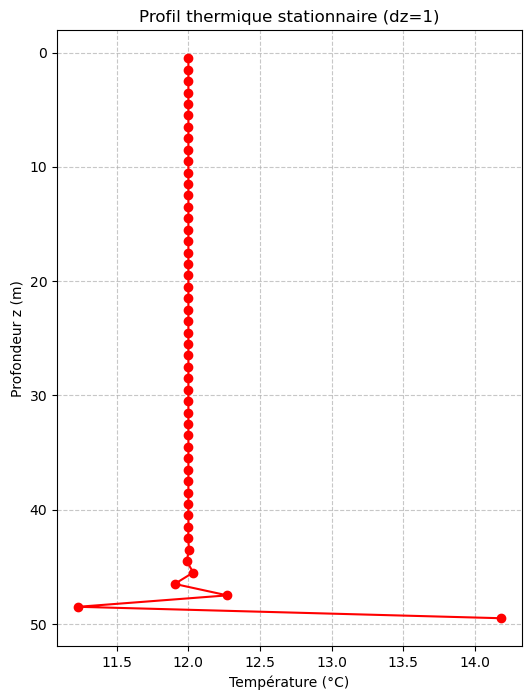

In [9]:
# Exemple d'utilisation et visualisation

visualisation(50, 1e-6, 1.0, 12.0, 10.0)

On voit que le code diverge, on va essayer un autre méthode :

On utilise le schéma décentré amont :
$$\rho_w c_w q \frac{\theta_i - \theta_{i-1}}{\Delta z} - \lambda_m \frac{\theta_{i+1} - 2\theta_i + \theta_{i-1}}{\Delta z^2} = 0$$

Les conditions aux limites s'écrivent donc :

- Pour la maille $i=1$

Commme, $\frac{\theta_0 + \theta_1}{2} = \theta_{haut} \implies \theta_0 = 2\theta_{haut} - \theta_1$

$$\rho_w c_w q \frac{\theta_1 - \theta_0}{\Delta z} - \lambda_m \frac{\theta_2 - 2\theta_1 + \theta_0}{\Delta z^2} = 0 \implies \rho_w c_w q \frac{2\theta_1 - 2\theta_{haut}}{\Delta z} - \lambda_m \frac{\theta_2 - 3\theta_1 + 2\theta_{haut}}{\Delta z^2} = 0$$

Soit, $\left( \frac{2\rho_w c_w q}{\Delta z} + \frac{3\lambda_m}{\Delta z^2} \right) \theta_1 + \left( - \frac{\lambda_m}{\Delta z^2} \right) \theta_2 = \left( \frac{2\rho_w c_w q}{\Delta z} + \frac{2\lambda_m}{\Delta z^2} \right) \theta_{haut}$

- De la même façon, pour la maille $i=n$

Puisque $\frac{\theta_n + \theta_{n+1}}{2} = \theta_{bas} \implies \theta_{n+1} = 2\theta_{bas} - \theta_n$,

$$\rho_w c_w q \frac{\theta_n - \theta_{n-1}}{\Delta z} - \lambda_m \frac{2\theta_{bas} - 3\theta_n + \theta_{n-1}}{\Delta z^2} = 0
\implies
\left( -\frac{\rho_w c_w q}{\Delta z} - \frac{\lambda_m}{\Delta z^2} \right) \theta_{n-1} + \left( \frac{\rho_w c_w q}{\Delta z} + \frac{3\lambda_m}{\Delta z^2} \right) \theta_n = \left( \frac{2\lambda_m}{\Delta z^2} \right) \theta_{bas}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def eq_chaleur_1d_new(n_cells, q, lambda_m, theta_haut, theta_bas, rho_w=1000.0, c_w=4180.0, dz=1.0):
    
    k_1 = lambda_m / (dz**2)
    k_2 = (rho_w * c_w * q) / dz 
    
    A = np.zeros((n_cells, n_cells))
    B = np.zeros(n_cells)
    
    # Condition limite haute (maille 0)
    A[0, 0] = 3 * k_1 + 2 * k_2
    A[0, 1] = -k_1
    B[0] = 2 * (k_1 + k_2) * theta_haut
    
    # Mailles internes
    for i in range(1, n_cells - 1):
        A[i, i - 1] = -k_1 - k_2
        A[i, i] = 2 * k_1 + k_2
        A[i, i + 1] = -k_1
        
    # Condition limite basse (maille n_cells-1)
    A[n_cells - 1, n_cells - 2] = -k_1 - k_2
    A[n_cells - 1, n_cells - 1] = 3 * k_1 + k_2
    B[n_cells - 1] = 2 * k_2 * theta_bas
    
    # Résolution
    theta = np.linalg.solve(A, B)
    z = np.arange(dz / 2, n_cells * dz, dz)
    
    return z, theta

def visualisation_new(n_cells, q, lambda_m, theta_haut, theta_bas):
    
    z_res, theta_res = eq_chaleur_1d_new(n_cells, q, lambda_m, theta_haut, theta_bas, dz=1.0)
    
    plt.figure(figsize=(6, 8))
    plt.plot(theta_res, z_res, marker='o', linestyle='-', color='r')
    plt.gca().invert_yaxis()
    plt.xlabel("Température (°C)")
    plt.ylabel("Profondeur z (m)")
    plt.title("Profil thermique stationnaire (Schéma Upwind)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

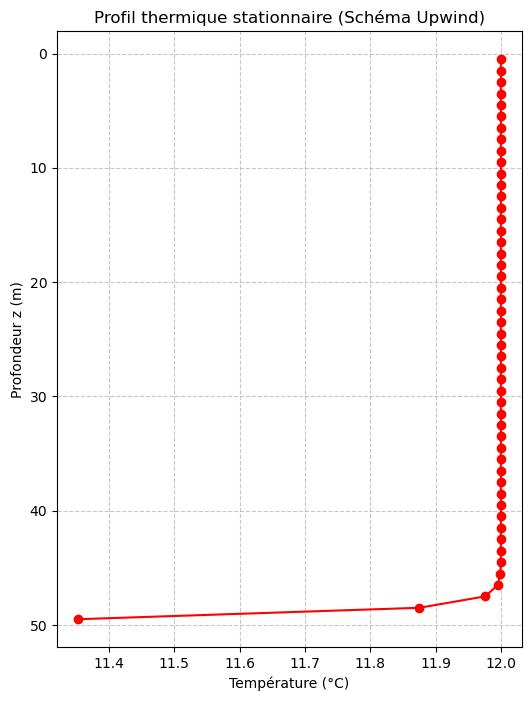

In [11]:
# Exemple d'utilisation et visualisation

visualisation_new(50, 1e-6, 1.0, 12.0, 10.0)

### 1.3. Ecrire une fonctionnalité du code permettant l'analyse de sensibilité

Il s'agit d'écrire une méthode permettant de lancer un calcul direct en spécifiant les valeurs des trois paramètres intervenant dans le système d'équations : 
+ la perméabilité 
+ la conductivité thermique 
+ la porosité cinématique

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# fonction precedente
def eq_chaleur_1d_new(n_cells, q, lambda_m, theta_haut, theta_bas, rho_w=1000.0, c_w=4180.0, dz=1.0):
    k_1 = lambda_m / (dz**2)
    k_2 = (rho_w * c_w * q) / dz 
    
    A = np.zeros((n_cells, n_cells))
    B = np.zeros(n_cells)
    
    # Condition limite haute (maille 0)
    A[0, 0] = 3 * k_1 + 2 * k_2
    A[0, 1] = -k_1
    B[0] = 2 * (k_1 + k_2) * theta_haut
    
    # Mailles internes
    for i in range(1, n_cells - 1):
        A[i, i - 1] = -k_1 - k_2
        A[i, i] = 2 * k_1 + k_2
        A[i, i + 1] = -k_1
        
    # Condition limite basse (maille n_cells-1)
    A[n_cells - 1, n_cells - 2] = -k_1 - k_2
    A[n_cells - 1, n_cells - 1] = 3 * k_1 + k_2
    B[n_cells - 1] = 2 * k_2 * theta_bas
    
    # Résolution
    theta = np.linalg.solve(A, B)
    z = np.arange(dz / 2, n_cells * dz, dz)
    
    return z, theta

def visualisation_new(n_cells, q, lambda_m, theta_haut, theta_bas):
    z_res, theta_res = eq_chaleur_1d_new(n_cells, q, lambda_m, theta_haut, theta_bas, dz=1.0)
    
    plt.figure(figsize=(6, 8))
    plt.plot(theta_res, z_res, marker='o', linestyle='-', color='r')
    plt.gca().invert_yaxis()
    plt.xlabel("Température (°C)")
    plt.ylabel("Profondeur z (m)")
    plt.title("Profil thermique stationnaire")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


# fonction de calcul direct

def lancer_calcul_hydrothermique(permeabilite, conductivite_thermique, porosite_cinematique, 
                                 gradient_hydraulique, theta_haut, theta_bas, n_cells=50):
    
    
    # Par loi de Darcy q = K * grad(h) où grad(h) = cte = i
    q_darcy = permeabilite * gradient_hydraulique
    
    # Vitesse de pore (vitesse réelle de l'eau)
    vitesse_interstitielle = q_darcy / porosite_cinematique

    # Affichage des valeurs avec IA
    print("--- Paramètres physiques injectés ---")
    print(f"Perméabilité (K)           : {permeabilite:.2e} m/s")
    print(f"Conductivité thermique     : {conductivite_thermique:.2f} W/(m.K)")
    print(f"Porosité cinématique       : {porosite_cinematique:.2f}")
    print("--- Grandeurs hydrauliques déduites ---")
    print(f"Gradient hydraulique (i)   : {gradient_hydraulique:.3f}")
    print(f"Flux de Darcy calculé (q)  : {q_darcy:.2e} m/s")
    print(f"Vitesse interstitielle (v) : {vitesse_interstitielle:.2e} m/s")
    print("-------------------------------------")
    
    visualisation_new(
        n_cells=n_cells,
        q=q_darcy, 
        lambda_m=conductivite_thermique, 
        theta_haut=theta_haut, 
        theta_bas=theta_bas
    )

--- Paramètres physiques injectés ---
Perméabilité (K)           : 1.00e-05 m/s
Conductivité thermique     : 2.50 W/(m.K)
Porosité cinématique       : 0.15
--- Grandeurs hydrauliques déduites ---
Gradient hydraulique (i)   : 0.020
Flux de Darcy calculé (q)  : 2.00e-07 m/s
Vitesse interstitielle (v) : 1.33e-06 m/s
-------------------------------------


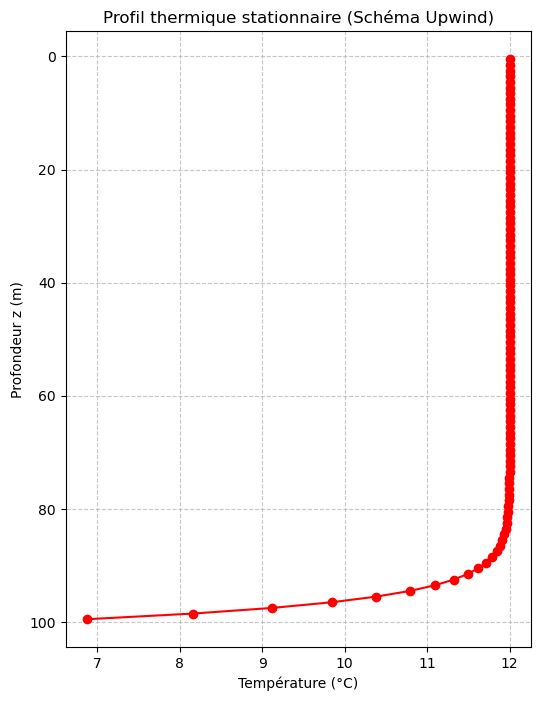

In [13]:
# Exemple d'utilisation et visualisation

lancer_calcul_hydrothermique(
    permeabilite=1e-5,
    conductivite_thermique=2.5,
    porosite_cinematique=0.15,
    gradient_hydraulique=0.02,
    theta_haut=12.0,
    theta_bas=18.0,
    n_cells=100
)

## 2. Régime thermique transitoire


### 2.1 Forme générale


On considère la convention de notation suivante. $\boldsymbol{\nabla}$ est un opérateur différenciel et $\Delta$ le Laplacien. 
Les symboles en gras représentent des vecteurs. 

L'interface nappe-rivière est ici représentée par une portion de zone hyporhéique mono-dimensionnelle de hauteur h.

Le couple d'équations régissant le transfert de chaleur correspond d'une part à la résolution du régime permanent hydraulique (loi de Darcy):

$ \boldsymbol{q} = -K \boldsymbol{\nabla} H $

avec $\boldsymbol{q}$, le débit spécifique [$m.s^{-1}$],  
$H$, la charge [$m$]  
$K$, la perméabilité [$m.s^{-1}$],

Le système expérimental MOLONARI (MOnitoring LOcal des échanges NAppe-RIvière) permet de mesurer la différence de pression entre le haut et le bas de la colonne, qui est ainsi une donnée d'entrée du problème. A perméabilité considérée homogène le long de la colonne, le débit est ainsi évaluable pour le couplage avec l'équation de transfert de chaleur en régime permanent :

$\rho_m c_m \dfrac{\partial \theta}{\partial t} = - \rho_w c_w \boldsymbol{q} \cdot \boldsymbol{\nabla} \theta + \lambda_m \Delta \theta$

avec $\theta$, la température [$K$],  
$\rho_i$, la densité de i [$kg.m^{-3}$],  
$c_i$ la capacité calorifique spécifique de i [$J.kg^{-1}.K^{-1}$],  
$\lambda_i$ [$W.m^{-1}.K^{-1}$] la conductivité thermique de i,
où $i \in {s,w,m}$, avec s solide, w eau, m milieu poreux equivalent. 

$c_m\rho_m$ est estimé à partir de moyenne volumique pondérée par la porosité $n$ du milieu, $ \rho_m c_m = n \rho_w c_w + (1 - n) \rho_s c_s $

La conductivité thermique du milieu poreux équivalent est estimée par la relation $\lambda_m = \left( n \sqrt{\lambda_w} + (1-n) \sqrt{\lambda_s} \right)^2$.

### 2.2 Réduction de l'espace des paramètres

L'équation de transport de la chaleur peut être réécrite sous la forme :


$ \dfrac{\partial \theta}{\partial t} = \kappa_e \Delta \theta + 
\alpha_e \boldsymbol{\nabla} H \cdot \boldsymbol{\nabla} \theta $

avec $ \kappa_e = \dfrac{\lambda_m}{ \rho_m c_m }  $

$ \alpha_e = \dfrac{\rho_w c_w}{ \rho_m c_m} K $


$\kappa_e$ [$m^2 s^{-1}$] et $\alpha_e$ [$m s^{-1}$] sont des paramètres effectifs, dénommés respectivement conductivité effective (parfois dénommée effective diffusivité thermique) et paramètre advectif effectif.

### 2.3 Propagation d'un signal périodique dans un milieu semi infini

Il existe une solution analytique, fournie par Stallman (1965), à la propagation d'un signal de température sinusoïdal  à la surface d'un milieu poreux soumis à une différence de pressions ($\Delta H$) constante au cours du temps. Le signal sinusoïdal est apliqué en haut de la colonne, dans un repère dont l'origine est en haut de la colonne et orienté vers le bas. Il a une amplitude  $\theta_{amp}$ et une période P autour d'une valeur moyenne $\theta_{\mu}$. Cette solution s'écrit :

$ \theta(z,t)  = \theta_{\mu} + \theta_{amp} e^{-az} \cos\left( \dfrac{2 \pi}{P} t - b z \right) $  [eq.1]

avec 
$ a  = \dfrac{1}{2 \kappa_e} \left( \sqrt{\dfrac{\sqrt{v_t^4 + (8 \pi \kappa_e / P)^2 } + v_t^2}{2}} - v_t \right) $, 

$ b  = \dfrac{1}{2 \kappa_e}  \sqrt{\dfrac{\sqrt{v_t^4 + (8 \pi \kappa_e / P)^2 } - v_t^2}{2}} $, 

$ v_t  = - \alpha_e \dfrac{\partial H}{\partial z} $


Dans le cas conductif pur, la solution analytique s'écrit:

$ \theta(z,t)  = \theta_{\mu} + \theta_{amp} e^{-\sqrt{\dfrac{\pi}{\kappa_e P}}z} \cos\left( \dfrac{2 \pi}{P} t - \sqrt{\dfrac{\pi}{\kappa_e P}} z \right) $  [eq.1cond]

### 2.4 Etude de cas

Considérons une colonne de sol de 8 m de profondeur avec la conductivité thermique équivalente $\lambda_m = 1 W.m^{-1}.K^{-1}$, la porosité $ n = 0.15$, et la capacité calorifique équivalente $\rho_m c_m =  4e6 J.m^{-3}.K^{-1}$. La perméabilité est fixée à $8.10^{-4} m.s^{-1}$. 

#### 2.4.1 Réponse de la zone hyporhéique à une sollicitation thermique périodique

On considère un signal périodique en surface d'amplitude 1 K et une période de 720 heures (30 jours) autour d'un température moyenne de 12 °C.

##### 2.4.1.1 Evolution de la température dans le milieu

Tracer le profil des températures toutes les 30 heures pour les trois cas suivants :

+ 1. vitesse de darcy vers le haut de 1e-6 $m. s^{-1}$
+ 2. profil conductif pur
+ 3.  vitesse de darcy vers le bas de 1e-6 $m. s^{-1}$

Avant de démarrer, écrire une méthode permettant de forcer une simulation à partir de paramètres thermiques équivalents (conductivité thermique et capacité calorifique).

Tracer également des frises temporelles représentant la matrice des températures dans l'espace (z,t). 

Commentez ces résultats.

##### 2.4.1.2 Quantifier et représentez les flux d'énergie relatifs à ces états thermiques

Tracer également des frises temporelles représentant les flux de chaleur advectifs et conductifs relatifs aux trois cas précédents. Commentez ces résultats.

##### 2.4.1.3 Profondeur de pénétration

Par convention on considère que la profondeur de pénétration d'une onde est définie par la profondeur à partir de laquelle l'amplitude est amortie de $e^{-1}$, soit environ d'un tiers.

__Calculer la profondeur de pénétration__

__Tracer les profondeurs de pénétration__ pour des signaux périodiques dont la période varie entre 1hr et 1 an. Pour des vitesses descendantes, ascendantes variant en valeur absolue entre 10$^{-5}$ et 10$^{-8}$ m.s$^{-1}$. On utilisera des échelles log.

Commentez ces résultats.

##### 2.4.1.4 Temps d'arrivée d'une perturbation à une profondeur donnée

En analysant la composante ondulatoire de a solution analytique [eq.1], définir le __temps d'arrivée__ à une profondeur $z$ d'une perturbation de période $P$. En déterminer la vitesse la vitesse de propagation de l'onde.

__Tracer les vitesses de propagation__ pour une gamme de vitesses variant entre 1e-5 m/s et 1e-8 m/s, et pour le cas conductif. Commentez vos résultats

#### 2.4.2 Sollicitations multi-périodiques
 
On considère maintenant deux signaux périodiques emboîtés, l'un annuel (d'amplitude 6 °C), l'autre journalier d'amplitude 1°C.

Représenter tout d'abord les deux influences séparemment puis voir comment elles se combinent dans le milieu pour les deux cas infliltrant et exfiltrant à une vitesse de Darcy de +/-1e-6 $m. s^{-1}$. Représentez les profils verticaux et les frises.

Commentez les résultats obtenus.

## 3. Modèle direct hydro-thermique

Intégrer la résolution transitoire de l'équation de la diffusivité à votre code afin d'obtenir un code capable de résoudre le problème hydro-thermique complet.